In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick, matplotlib.dates as mdates

In [4]:
data = pd.read_csv("indices_region.csv")

In [10]:
data['region'] = data['region'].apply(lambda x: 'Amazonía' if x=='Amazon�a' else x)
data['region'] = data['region'].apply(lambda x: 'Galápagos' if x=='Gal�pagos' else x)
data['region'] = data['region'].apply(lambda x: 'Manabí' if x=='Manab�' else x)
data['region'] = data['region'].apply(lambda x: 'Los Ríos' if x=='Los R�os' else x)  

In [12]:
data['region'].value_counts()

region
Amazonía                139
Azuay                   139
Costa, Santo Domingo    139
El Oro                  139
Guayas                  139
Los Ríos                139
Manabí                  139
Pichincha               139
Sierra                  139
Galápagos               139
Name: count, dtype: int64

In [25]:
region = 'Azuay'

In [26]:
df = data.loc[data['region'] == region]

In [27]:
df['periodo'] = df.apply(lambda x: str(int(x['ano'])) + "-T" + str(int(x['trimestre'])), axis=1)

/tmp/ipykernel_53962/1842749766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['periodo'] = df.apply(lambda x: str(int(x['ano'])) + "-T" + str(int(x['trimestre'])), axis=1)


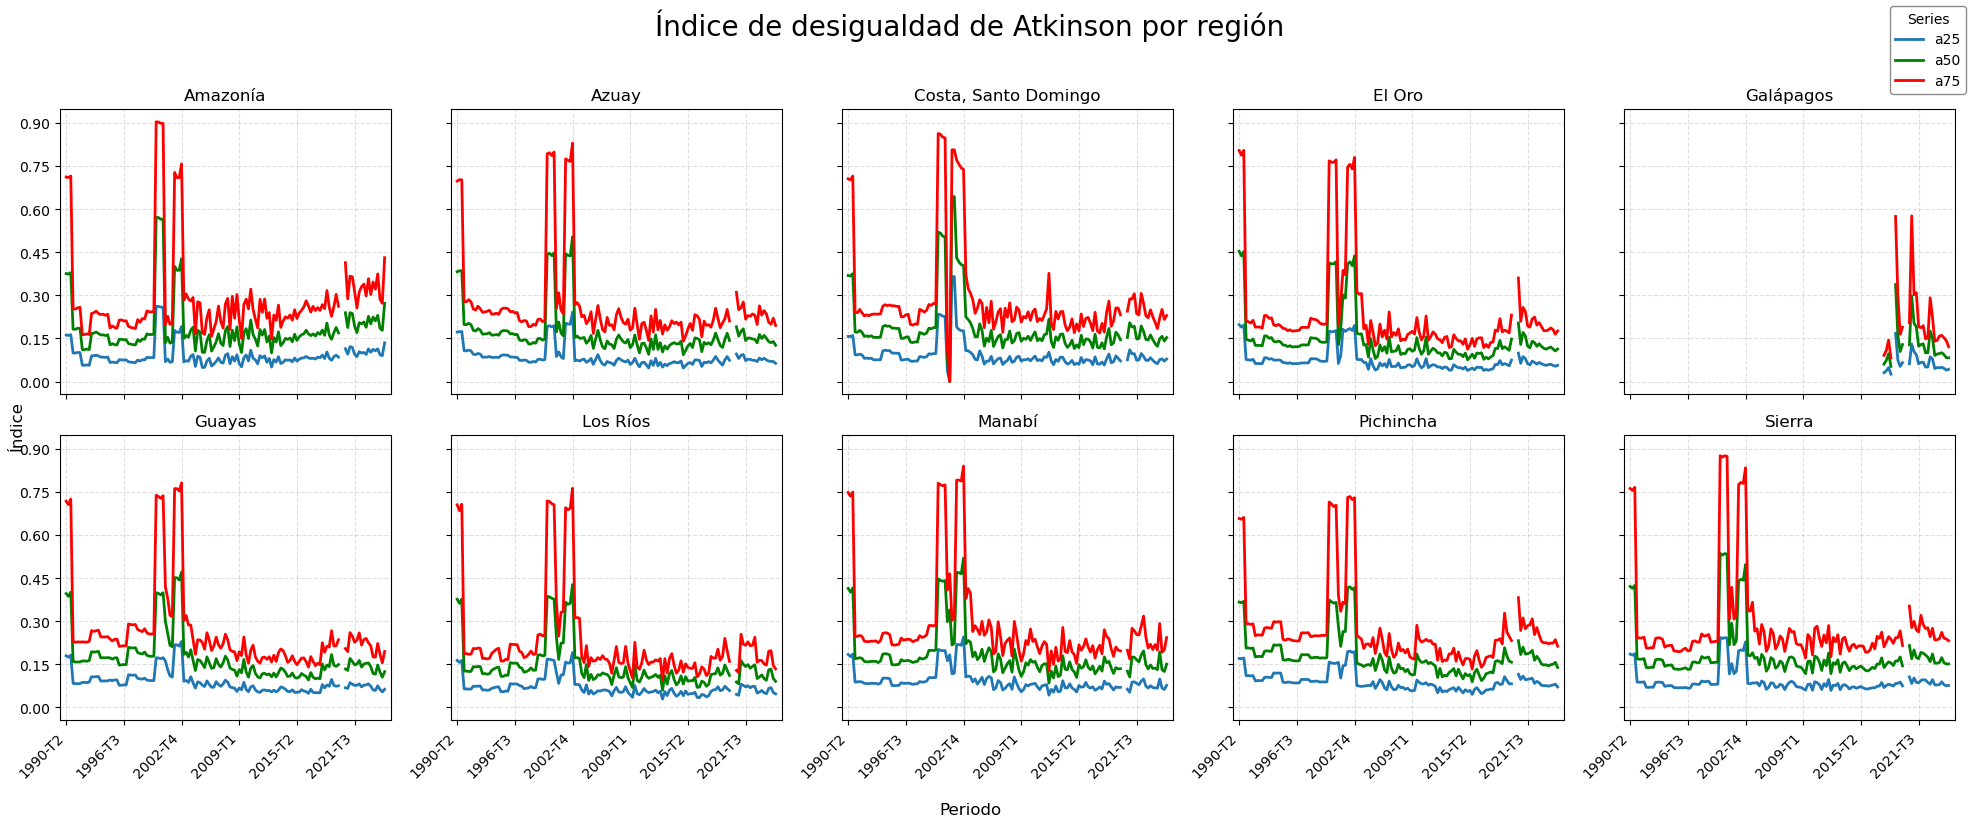

In [29]:
# Create "periodo" once for the whole DataFrame
data = data.copy()
data['periodo'] = data.apply(
    lambda x: f"{int(x['ano'])}-T{int(x['trimestre'])}", axis=1
)

regions = sorted(data['region'].unique())  # 10 unique regions
n_regions = len(regions)

# Decide grid shape (e.g. 2 rows x 5 columns)
n_rows = 2
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # make it 1D for easy indexing

for i, region in enumerate(regions):
    ax = axes[i]
    df = data.loc[data['region'] == region].sort_values(['ano', 'trimestre'])

    x = df['periodo']
    y = df['a25']
    y1 = df['a50']
    y2 = df['a75']

    ax.plot(x, y,  linewidth=2, label='a25', color="#1f77b4")
    ax.plot(x, y1, linewidth=2, label='a50', color='green')
    ax.plot(x, y2, linewidth=2, label='a75', color="red")

    # axes formatting (per subplot)
    ax.set_title(region, fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)

# Apply y-axis percent formatting if appropriate (using whole data or first region)
min_y = min(data['a25'].min(), data['a50'].min(), data['a75'].min())
max_y = max(data['a25'].max(), data['a50'].max(), data['a75'].max())
if (min_y >= 0) and (max_y <= 1.05):
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
else:
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))

# Hide any unused subplots (if n_regions < n_rows * n_cols)
for j in range(n_regions, len(axes)):
    fig.delaxes(axes[j])

# Global labels and legend
fig.suptitle('Índice de desigualdad de Atkinson por región', fontsize=20, y=1.02)
fig.supxlabel('Periodo')
fig.supylabel('Índice')

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True, framealpha=0.9,
           facecolor='white', edgecolor='gray', title='Series')

plt.margins(x=0.02)
plt.tight_layout()
plt.show()

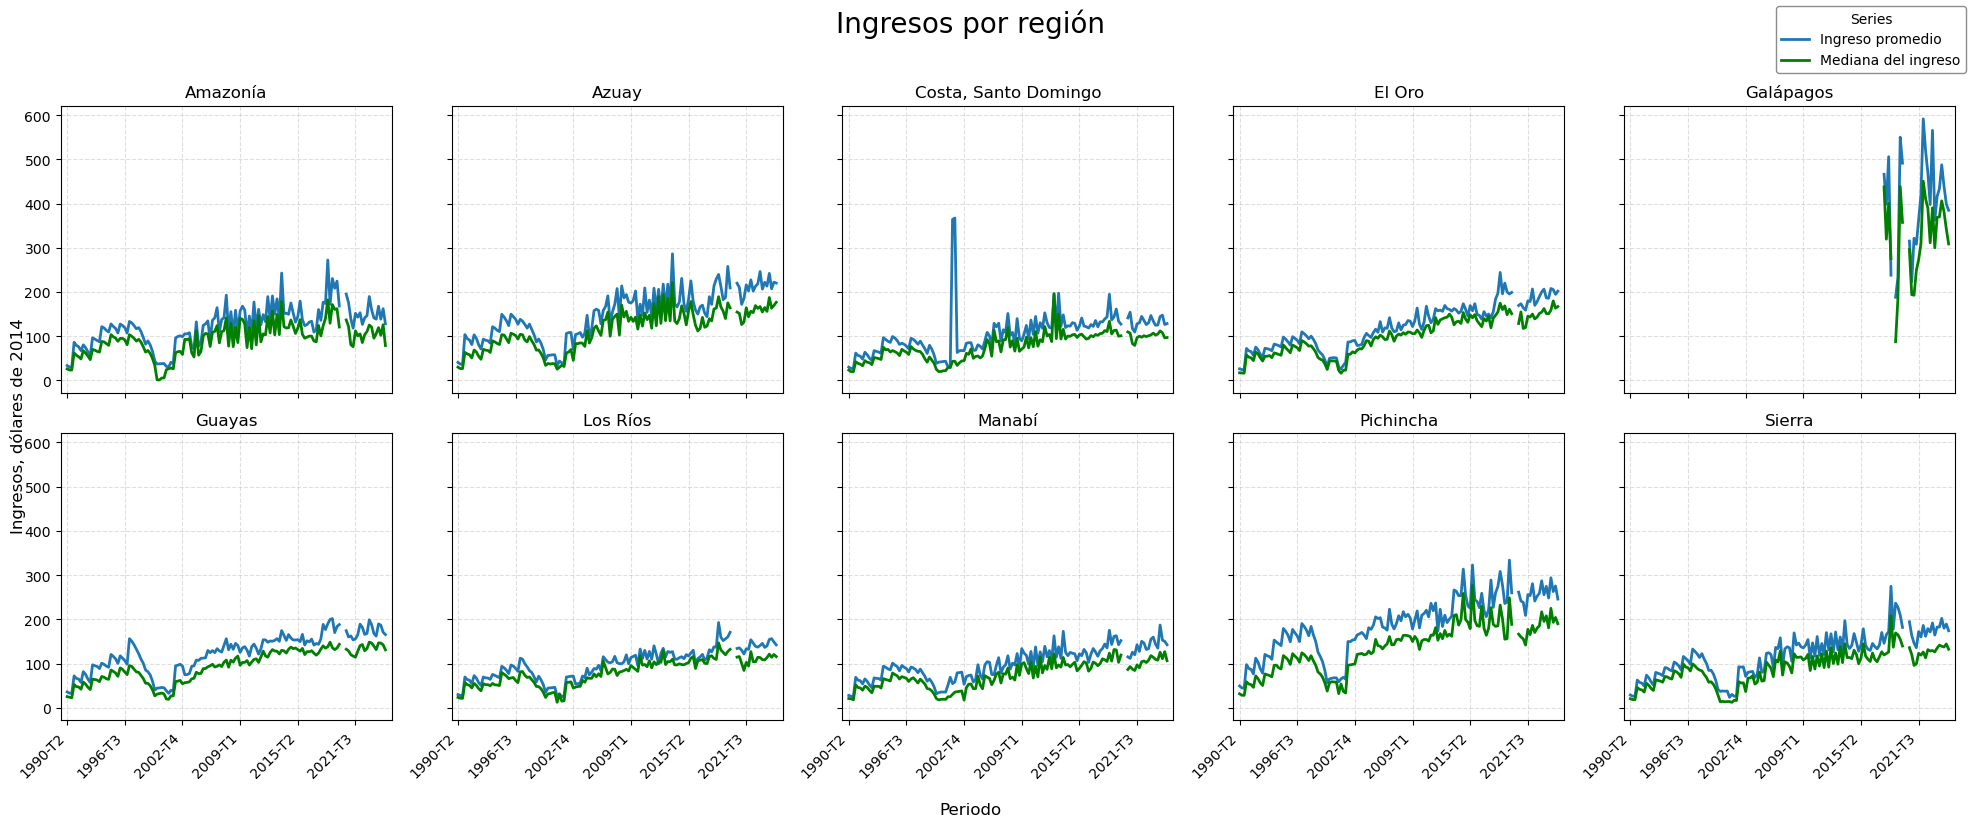

In [32]:
# Create "periodo" once for the whole DataFrame
data = data.copy()
data['periodo'] = data.apply(
    lambda x: f"{int(x['ano'])}-T{int(x['trimestre'])}", axis=1
)

regions = sorted(data['region'].unique())  # 10 unique regions
n_regions = len(regions)

# Decide grid shape (e.g. 2 rows x 5 columns)
n_rows = 2
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # make it 1D for easy indexing

for i, region in enumerate(regions):
    ax = axes[i]
    df = data.loc[data['region'] == region].sort_values(['ano', 'trimestre'])

    x = df['periodo']
    y = df['ingreso_promedio']
    y1 = df['ingreso_mediana']

    ax.plot(x, y,  linewidth=2, label='Ingreso promedio', color="#1f77b4")
    ax.plot(x, y1, linewidth=2, label='Mediana del ingreso', color='green')
    
    # axes formatting (per subplot)
    ax.set_title(region, fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)

# Apply y-axis percent formatting if appropriate (using whole data or first region)
min_y = min(data['ingreso_promedio'].min(), data['ingreso_mediana'].min())
max_y = max(data['ingreso_promedio'].max(), data['ingreso_mediana'].max())
if (min_y >= 0) and (max_y <= 1.05):
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
else:
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))

# Hide any unused subplots (if n_regions < n_rows * n_cols)
for j in range(n_regions, len(axes)):
    fig.delaxes(axes[j])

# Global labels and legend
fig.suptitle('Ingresos por región', fontsize=20, y=1.02)
fig.supxlabel('Periodo')
fig.supylabel('Ingresos, dólares de 2014')

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True, framealpha=0.9,
           facecolor='white', edgecolor='gray', title='Series')

plt.margins(x=0.02)
plt.tight_layout()
plt.show()

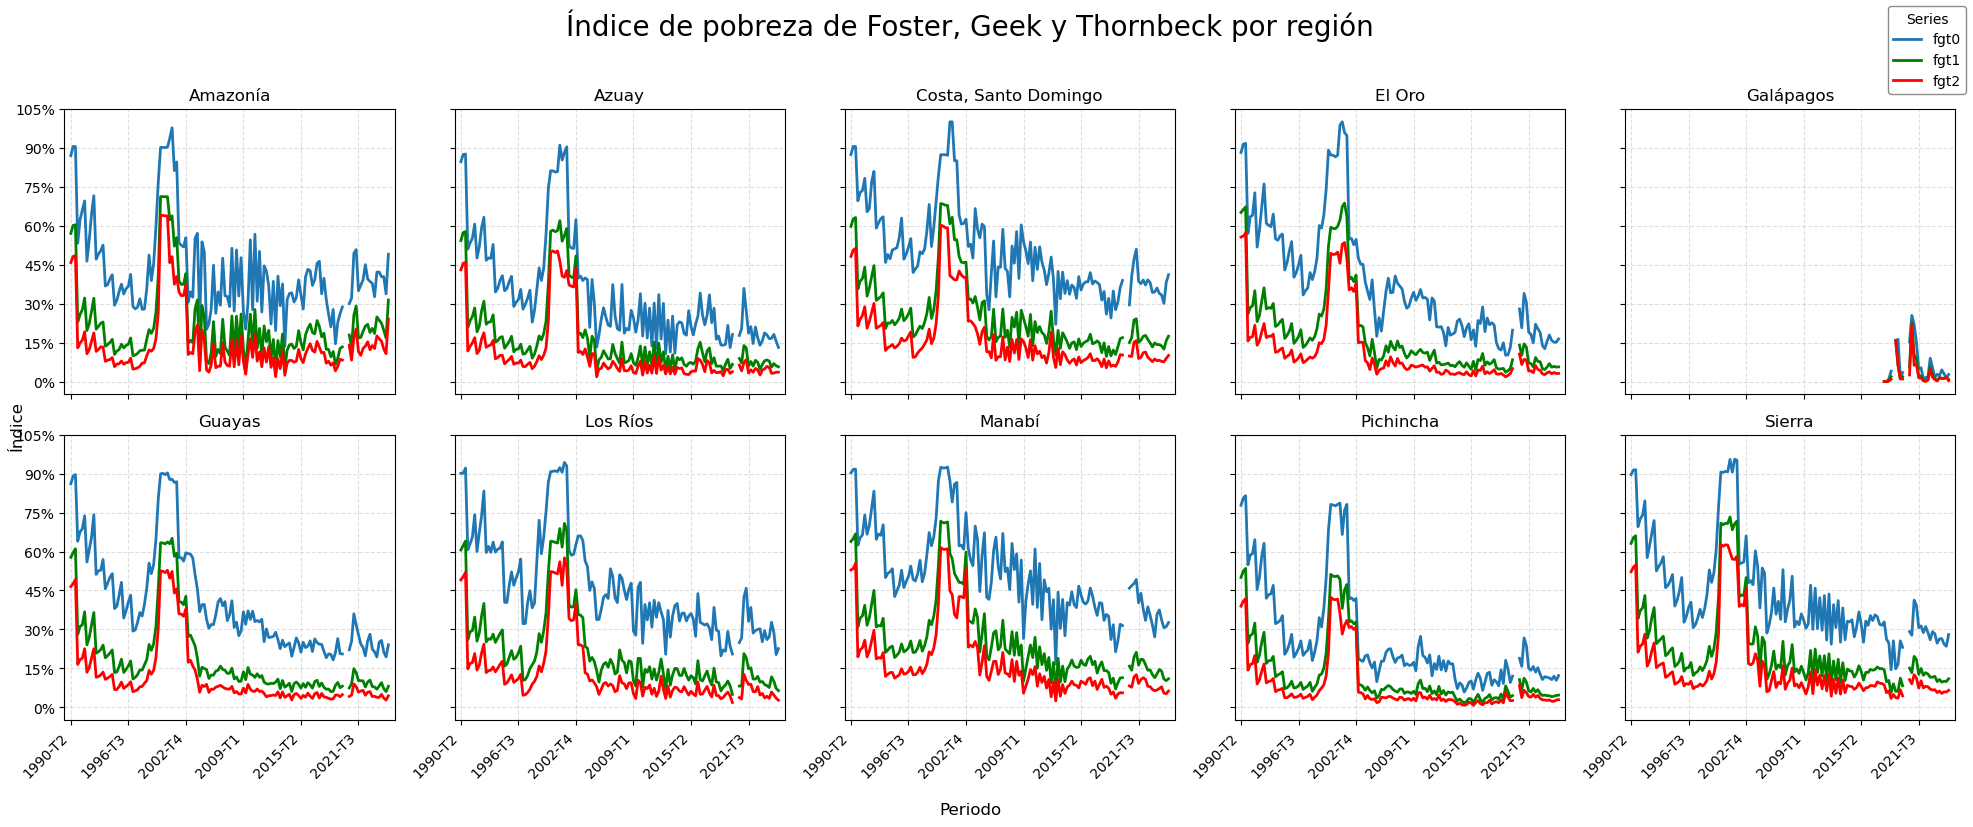

In [34]:
# Create "periodo" once for the whole DataFrame
data = data.copy()
data['periodo'] = data.apply(
    lambda x: f"{int(x['ano'])}-T{int(x['trimestre'])}", axis=1
)

regions = sorted(data['region'].unique())  # 10 unique regions
n_regions = len(regions)

# Decide grid shape (e.g. 2 rows x 5 columns)
n_rows = 2
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # make it 1D for easy indexing

for i, region in enumerate(regions):
    ax = axes[i]
    df = data.loc[data['region'] == region].sort_values(['ano', 'trimestre'])

    x = df['periodo']
    y = df['fgt0']
    y1 = df['fgt1']
    y2 = df['fgt2']

    ax.plot(x, y,  linewidth=2, label='fgt0', color="#1f77b4")
    ax.plot(x, y1, linewidth=2, label='fgt1', color='green')
    ax.plot(x, y2, linewidth=2, label='fgt2', color="red")

    # axes formatting (per subplot)
    ax.set_title(region, fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)

# Apply y-axis percent formatting if appropriate (using whole data or first region)
min_y = min(data['fgt0'].min(), data['fgt1'].min(), data['fgt2'].min())
max_y = max(data['fgt0'].max(), data['fgt1'].max(), data['fgt2'].max())
if (min_y >= 0) and (max_y <= 1.05):
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
else:
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))

# Hide any unused subplots (if n_regions < n_rows * n_cols)
for j in range(n_regions, len(axes)):
    fig.delaxes(axes[j])

# Global labels and legend
fig.suptitle('Índice de pobreza de Foster, Geek y Thornbeck por región', fontsize=20, y=1.02)
fig.supxlabel('Periodo')
fig.supylabel('Índice')

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True, framealpha=0.9,
           facecolor='white', edgecolor='gray', title='Series')

plt.margins(x=0.02)
plt.tight_layout()
plt.show()

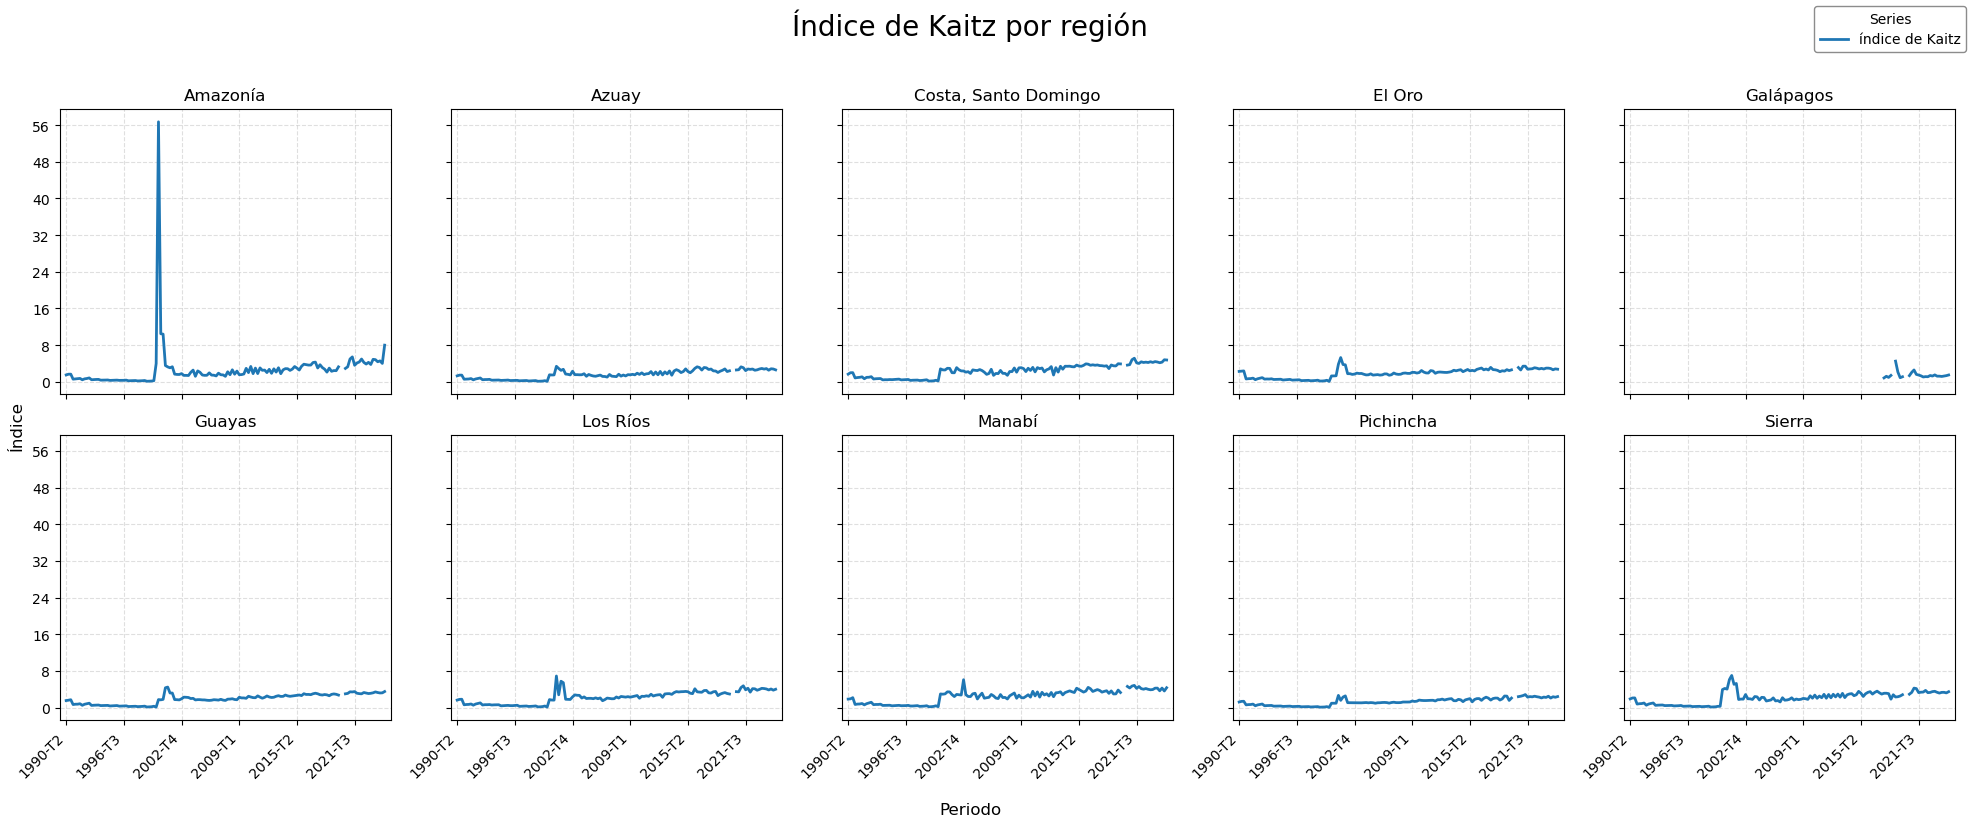

In [36]:
# Create "periodo" once for the whole DataFrame
data = data.copy()
data['periodo'] = data.apply(
    lambda x: f"{int(x['ano'])}-T{int(x['trimestre'])}", axis=1
)

regions = sorted(data['region'].unique())  # 10 unique regions
n_regions = len(regions)

# Decide grid shape (e.g. 2 rows x 5 columns)
n_rows = 2
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()  # make it 1D for easy indexing

for i, region in enumerate(regions):
    ax = axes[i]
    df = data.loc[data['region'] == region].sort_values(['ano', 'trimestre'])

    x = df['periodo']
    y = df['kaitz_indice']

    ax.plot(x, y,  linewidth=2, label='índice de Kaitz', color="#1f77b4")
    
    # axes formatting (per subplot)
    ax.set_title(region, fontsize=12)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)

# Apply y-axis percent formatting if appropriate (using whole data or first region)
min_y = data['kaitz_indice'].min()
max_y = data['kaitz_indice'].max()
if (min_y >= 0) and (max_y <= 1.05):
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
else:
    for ax in axes:
        ax.yaxis.set_major_locator(plt.MaxNLocator(8))

# Hide any unused subplots (if n_regions < n_rows * n_cols)
for j in range(n_regions, len(axes)):
    fig.delaxes(axes[j])

# Global labels and legend
fig.suptitle('Índice de Kaitz por región', fontsize=20, y=1.02)
fig.supxlabel('Periodo')
fig.supylabel('Índice')

# One global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True, framealpha=0.9,
           facecolor='white', edgecolor='gray', title='Series')

plt.margins(x=0.02)
plt.tight_layout()
plt.show()